# Install libraries

In [ ]:
!pip install kagglehub

import kagglehub
import os
from pathlib import Path

# Download Dataset

In [ ]:
# Download the latest version of the BRISC 2025 dataset
dataset_path = kagglehub.dataset_download("briscdataset/brisc2025")
print("Path to dataset files:", dataset_path)

100%|██████████| 250M/250M [00:06<00:00, 38.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6


# List Directory

In [ ]:
from pathlib import Path

# Convert dataset_path to a Path object for easier manipulation
dataset_path = Path(dataset_path)

print("Top-level contents:")
for item in dataset_path.iterdir():
    print(item)

print("\nRecursive structure (limited to 10 files per folder for brevity):")
def list_limited(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(str(startpath), '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        for f in files[:10]:
            print(f"{subindent}{f}")
        if len(files) > 10:
            print(f"{subindent}... ({len(files) - 10} more files)")

list_limited(dataset_path)

Top-level contents:
/root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025

Recursive structure (limited to 10 files per folder for brevity):
6/
    brisc2025/
        manifest.csv.sha256
        manifest.csv
        README.md
        manifest.json.sha256
        manifest.json
        segmentation_task/
            test/
                masks/
                    brisc2025_test_00492_me_sa_t1.png
                    brisc2025_test_00221_gl_sa_t1.png
                    brisc2025_test_00793_pi_ax_t1.png
                    brisc2025_test_00228_gl_sa_t1.png
                    brisc2025_test_00721_pi_ax_t1.png
                    brisc2025_test_00441_me_co_t1.png
                    brisc2025_test_00758_pi_ax_t1.png
                    brisc2025_test_00150_gl_co_t1.png
                    brisc2025_test_00857_pi_co_t1.png
                    brisc2025_test_00993_pi_sa_t1.png
                    ... (850 more files)
                images/
                    brisc202

# Data Preprocessing

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, losses, metrics, callbacks
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import os
from pathlib import Path
from sklearn.model_selection import train_test_split

base_path = Path(dataset_path) / 'brisc2025'

# Verify the path exists
print("Base path exists:", base_path.exists())
print("Contents:", list(base_path.iterdir()))

# Segmentation task directories
train_img_dir = base_path / 'segmentation_task' / 'train' / 'images'
train_mask_dir = base_path / 'segmentation_task' / 'train' / 'masks'
test_img_dir = base_path / 'segmentation_task' / 'test' / 'images'
test_mask_dir = base_path / 'segmentation_task' / 'test' / 'masks'

# Collect image paths (JPG)
train_image_paths = sorted(glob(str(train_img_dir / '*.jpg')))
test_image_paths = sorted(glob(str(test_img_dir / '*.jpg')))

print(f"\nTrain images found: {len(train_image_paths)}")
print(f"Test images found: {len(test_image_paths)}")

# Pair masks by replacing directory and extension
train_mask_paths = [str(p).replace('images', 'masks').replace('.jpg', '.png') for p in train_image_paths]
test_mask_paths = [str(p).replace('images', 'masks').replace('.jpg', '.png') for p in test_image_paths]

# Verify a few pairs exist
print("Sample train image:", os.path.basename(train_image_paths[0]))
print("Corresponding mask:", os.path.basename(train_mask_paths[0]))
print("Mask file exists:", os.path.exists(train_mask_paths[0]))

# Split train into train (80%) + validation (20%)
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    train_image_paths, train_mask_paths, test_size=0.2, random_state=42, stratify=None)

print(f"\nFinal splits:")
print(f"  Training: {len(train_imgs)} images")
print(f"  Validation: {len(val_imgs)} images")
print(f"  Test (held-out): {len(test_image_paths)} images")

# Preprocessing function (binary segmentation, JPG images)
def load_and_preprocess(img_path, mask_path):
    # Load JPEG image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=1)  # Grayscale T1-weighted
    img = tf.image.resize(img, [256, 256])
    img = tf.cast(img, tf.float32) / 255.0

    # Load PNG mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [256, 256], method='nearest')
    mask = tf.cast(mask, tf.float32) / 255.0  # Normalize (0 or 255 → 0.0 or 1.0)
    mask = tf.where(mask > 0.5, 1.0, 0.0)     # Ensure strict binary

    return img, mask

# Augmentation
def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    # rotation for varied orientations (ax/co/sa)
    if tf.random.uniform(()) > 0.5:
        angle = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
        img = tf.image.rot90(img, k=angle)
        mask = tf.image.rot90(mask, k=angle)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.5, 2.0)
    return img, mask

# Dataset creation
BATCH_SIZE = 16

# Runtime environment info
import platform, sys

print("─" * 60)
print("─" * 15, "Environment Info", "─" * 15)
print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("Platform:", platform.platform())
print("BATCH_SIZE:", BATCH_SIZE)

gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)
if gpus:
    try:
        details = tf.config.experimental.get_device_details(gpus[0])
        print("GPU details:", details)
    except Exception as e:
        print("Could not fetch GPU details:", e)

def create_dataset(img_paths, mask_paths, augment_data=False, shuffle_data=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle_data:
        ds = ds.shuffle(buffer_size=1000, seed=42)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_imgs, train_masks, augment_data=True, shuffle_data=True)
val_ds = create_dataset(val_imgs, val_masks, augment_data=False, shuffle_data=False)
test_ds = create_dataset(test_image_paths, test_mask_paths, augment_data=False, shuffle_data=False)

Base path exists: True
Contents: [PosixPath('/root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025/manifest.csv.sha256'), PosixPath('/root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025/manifest.csv'), PosixPath('/root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025/segmentation_task'), PosixPath('/root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025/README.md'), PosixPath('/root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025/classification_task'), PosixPath('/root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025/manifest.json.sha256'), PosixPath('/root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025/manifest.json')]

Train images found: 3933
Test images found: 860
Sample train image: brisc2025_train_00001_gl_ax_t1.jpg
Corresponding mask: brisc2025_train_00001_gl_ax_t1.png
Mask file exists: True

Final splits:
  Training: 3146 images

### Data Augmentation Samples

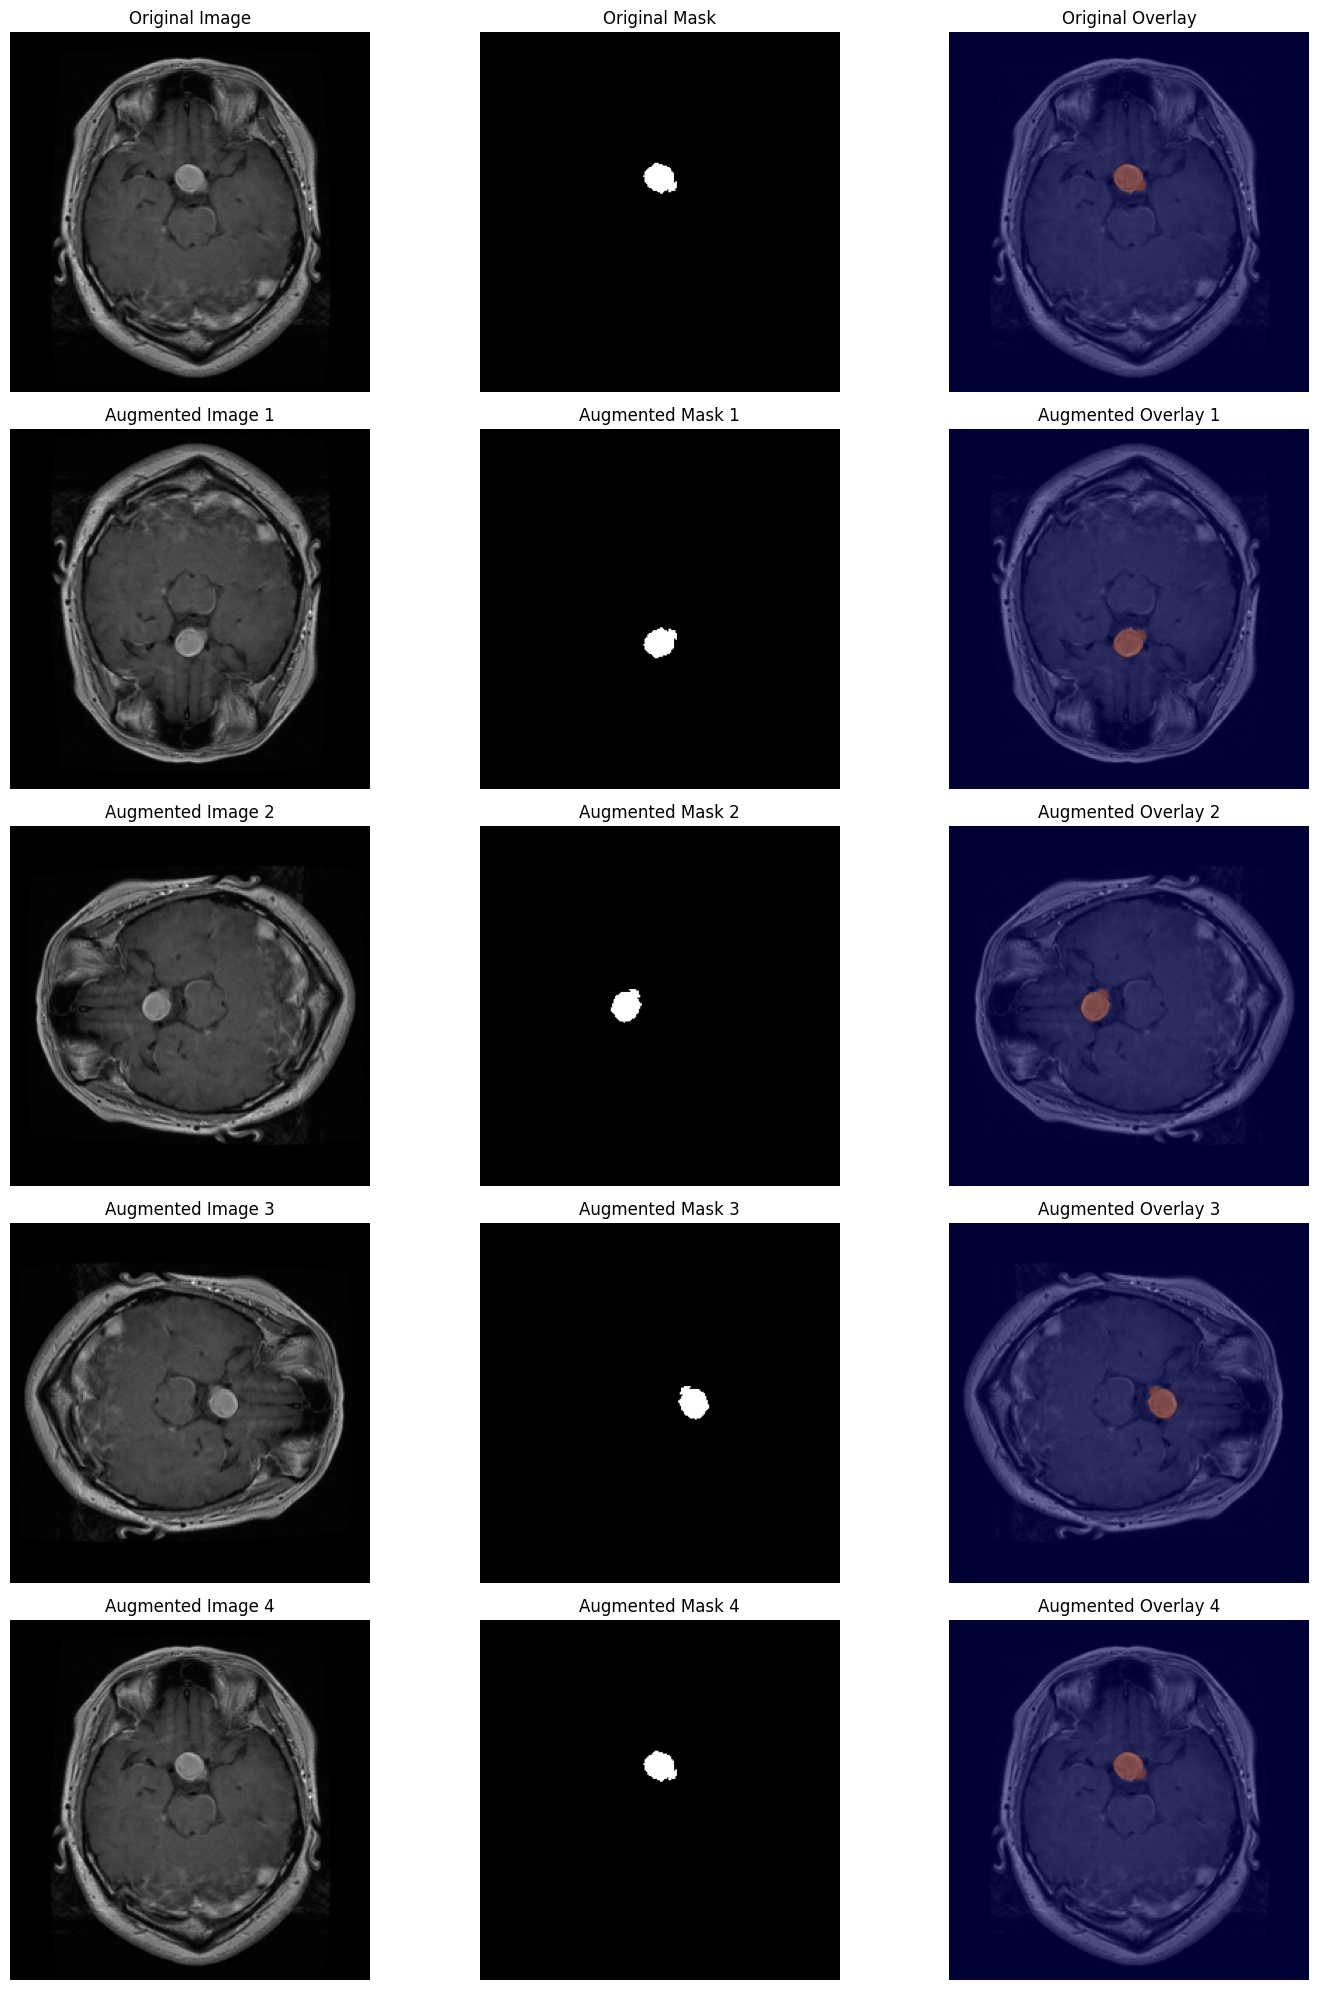

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get one original sample from the training dataset (before augmentation mapping)
# To get an 'original' sample, we need to bypass the augmentation in train_ds.
# We can create a temporary dataset without augmentation for this purpose.

# Get a raw image and mask path
img_path_raw = train_imgs[0]
mask_path_raw = train_masks[0]

# Load and preprocess the original image and mask without augmentation
original_img, original_mask = load_and_preprocess(img_path_raw, mask_path_raw)


num_augmentation_samples = 4 # Number of augmented samples to show

plt.figure(figsize=(15, 4 * (num_augmentation_samples + 1)))

# Display original image and mask
plt.subplot(num_augmentation_samples + 1, 3, 1)
plt.title("Original Image")
plt.imshow(original_img[:, :, 0], cmap='gray')
plt.axis('off')

plt.subplot(num_augmentation_samples + 1, 3, 2)
plt.title("Original Mask")
plt.imshow(original_mask[:, :, 0], cmap='gray')
plt.axis('off')

plt.subplot(num_augmentation_samples + 1, 3, 3)
plt.title("Original Overlay")
plt.imshow(original_img[:, :, 0], cmap='gray')
plt.imshow(original_mask[:, :, 0], cmap='jet', alpha=0.4)
plt.axis('off')


for i in range(num_augmentation_samples):
    # Apply augmentation to the original sample
    augmented_img, augmented_mask = augment(original_img, original_mask)

    plt.subplot(num_augmentation_samples + 1, 3, (i + 1) * 3 + 1)
    plt.title(f"Augmented Image {i+1}")
    plt.imshow(augmented_img[:, :, 0], cmap='gray')
    plt.axis('off')

    plt.subplot(num_augmentation_samples + 1, 3, (i + 1) * 3 + 2)
    plt.title(f"Augmented Mask {i+1}")
    plt.imshow(augmented_mask[:, :, 0], cmap='gray')
    plt.axis('off')

    plt.subplot(num_augmentation_samples + 1, 3, (i + 1) * 3 + 3)
    plt.title(f"Augmented Overlay {i+1}")
    plt.imshow(augmented_img[:, :, 0], cmap='gray')
    plt.imshow(augmented_mask[:, :, 0], cmap='jet', alpha=0.4)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Evaluation Function

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# ────────────────────────────────────────────────────────────────
# Helper metrics (NumPy, stable + report-friendly)
# ────────────────────────────────────────────────────────────────
def dice_np(y_true, y_pred, eps=1e-6):
    """Dice for binary masks (flattened or not)."""
    y_true = y_true.astype(np.uint8).reshape(-1)
    y_pred = y_pred.astype(np.uint8).reshape(-1)
    inter = np.sum(y_true * y_pred)
    denom = np.sum(y_true) + np.sum(y_pred)
    return (2.0 * inter + eps) / (denom + eps)

def iou_np(y_true, y_pred, eps=1e-6):
    """IoU for binary masks (flattened or not)."""
    y_true = y_true.astype(np.uint8).reshape(-1)
    y_pred = y_pred.astype(np.uint8).reshape(-1)
    inter = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - inter
    return (inter + eps) / (union + eps)

# ────────────────────────────────────────────────────────────────
# Evaluation function for binary segmentation
# ────────────────────────────────────────────────────────────────
def evaluate_model(model_name, model, test_ds, threshold=0.5, num_examples=5):
    """
    Evaluates a binary segmentation model on the test dataset.

    Metrics (pixel-level, flattened):
    - Dice Coefficient
    - IoU (Jaccard Index)
    - Precision
    - Recall
    - Pixel Accuracy

    Also generates:
    - Qualitative predictions (num_examples)
    """
    print(f"\nEvaluating model: {model_name}")
    print("\nSummary\n")

    all_y_true = []
    all_y_pred = []
    all_y_pred_prob = []

    # Iterate over the entire test dataset
    for img_batch, mask_batch in test_ds:
        pred_batch = model.predict(img_batch, verbose=0)  # (B, H, W, 1)

        # Flatten for pixel-level metrics
        y_true_flat = mask_batch.numpy().astype(np.uint8).flatten()
        y_prob_flat = pred_batch.astype(np.float32).flatten()
        y_pred_flat = (pred_batch >= threshold).astype(np.uint8).flatten()

        all_y_true.append(y_true_flat)
        all_y_pred_prob.append(y_prob_flat)
        all_y_pred.append(y_pred_flat)

    # Concatenate all batches
    y_true = np.concatenate(all_y_true).astype(np.uint8)
    y_pred_prob = np.concatenate(all_y_pred_prob).astype(np.float32)
    y_pred = np.concatenate(all_y_pred).astype(np.uint8)

    # ─── Core overlap metrics (binary) ─────────────────────────────
    dice = float(dice_np(y_true, y_pred))
    iou  = float(iou_np(y_true, y_pred))

    # ─── Precision / Recall / Accuracy (pixel-level) ───────────────
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    precision = float(tp / (tp + fp + 1e-6)) if (tp + fp) > 0 else 0.0
    recall    = float(tp / (tp + fn + 1e-6)) if (tp + fn) > 0 else 0.0
    pixel_acc = float(np.mean(y_true == y_pred))

    # ─── Print summary ─────────────────────────────────────────────
    print("─" * 60)
    print(f"Pixel-level Metrics (threshold = {threshold}):")
    print(f"  Dice Coefficient:     {dice:.4f}")
    print(f"  IoU (Jaccard Index):  {iou:.4f}")
    print(f"  Precision:            {precision:.4f}")
    print(f"  Recall:               {recall:.4f}")
    print(f"  Pixel Accuracy:       {pixel_acc:.4f}")
    print("─" * 60)

    metrics_dict = {
        "Dice": dice,
        "IoU": iou,
        "Precision": precision,
        "Recall": recall,
        "Pixel Accuracy": pixel_acc
    }

    # ─── Qualitative: Show random predictions ───────────────────────
    print(f"\n Qualitative predictions – {num_examples} sample cases\n")

    # Shuffle only for visualization (does NOT affect earlier evaluation)
    viz_ds = test_ds.shuffle(buffer_size=500, seed=42)

    shown = 0
    plt.figure(figsize=(18, 4 * num_examples))

    for imgs, masks in viz_ds:
        preds = model.predict(imgs, verbose=0)
        preds_bin = (preds >= threshold).astype(np.uint8)

        for i in range(imgs.shape[0]):
            if shown >= num_examples:
                break

            # If grayscale, channel 0 is fine; if RGB, this still displays channel 0.
            plt.subplot(num_examples, 4, shown * 4 + 1)
            plt.imshow(imgs[i, :, :, 0], cmap='gray')
            plt.title("Image")
            plt.axis('off')

            plt.subplot(num_examples, 4, shown * 4 + 2)
            plt.imshow(masks[i, :, :, 0], cmap='gray')
            plt.title("Original Mask")
            plt.axis('off')

            plt.subplot(num_examples, 4, shown * 4 + 3)
            plt.imshow(preds_bin[i, :, :, 0], cmap='gray')
            plt.title("Prediction")
            plt.axis('off')

            # Dice per sample (binary)
            sample_dice = dice_np(masks[i, :, :, 0].numpy(), preds_bin[i, :, :, 0])
            plt.subplot(num_examples, 4, shown * 4 + 4)
            plt.text(0.5, 0.5, f"Dice: {sample_dice:.3f}", ha='center', va='center', fontsize=12)
            plt.axis('off')

            shown += 1

        if shown >= num_examples:
            break

    plt.tight_layout()
    plt.savefig(f'predictions_{model_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

    return metrics_dict

In [ ]:
def get_param_counts(model):
    total = int(model.count_params())
    trainable = int(np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]))
    non_trainable = int(np.sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights]))
    return {
        "Total Params": total,
        "Trainable Params": trainable,
        "Non-trainable Params": non_trainable
    }

In [ ]:
### Approximate inference latency measured using model.predict (includes framework overhead).
import time

def benchmark_latency_ms_per_image(model, ds, warmup_batches=3, timed_batches=10):
    """
    Benchmarks inference latency in ms/image on a dataset.
    Uses warm-up to stabilize graph/CPU/GPU kernels.
    """
    # Grab a limited iterator (no shuffle)
    it = iter(ds)

    # Warm-up
    for _ in range(warmup_batches):
        imgs, _ = next(it)
        _ = model.predict(imgs, verbose=0)

    # Timed runs
    times = []
    n_images = 0

    for _ in range(timed_batches):
        imgs, _ = next(it)
        bs = imgs.shape[0]
        t0 = time.perf_counter()
        _ = model.predict(imgs, verbose=0)
        t1 = time.perf_counter()

        times.append(t1 - t0)
        n_images += int(bs)

    total_time = float(np.sum(times))
    ms_per_image = (total_time / n_images) * 1000.0

    # Also useful: variance across batches
    ms_per_batch = (np.array(times) * 1000.0)
    return {
        "Latency (ms/img)": float(ms_per_image),
        "Latency batch ms mean": float(ms_per_batch.mean()),
        "Latency batch ms std": float(ms_per_batch.std())
    }

# Classic U-Net Model Architecture

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, metrics
import matplotlib.pyplot as plt
import numpy as np

# Binary Dice Coefficient and Loss
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

# Binary IoU
def binary_iou(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(tf.where(y_pred > 0.5, 1.0, 0.0))
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Classic U-Net for Binary Segmentation (~31M params)
def build_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(c5)

    # Decoder with skip connections
    u6 = layers.Conv2DTranspose(512, 2, strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, 3, activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, 2, strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, 3, activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, 3, activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, 3, activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, 3, activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, 3, activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c9)  # Binary: sigmoid

    model = models.Model(inputs, outputs, name='U-Net')
    return model

In [ ]:
# Build and compile
U_net_model = build_unet()
U_net_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,  # BCE + Dice for better convergence
    metrics=[dice_coef, binary_iou, 'binary_accuracy']
)

U_net_model.summary()

# Callbacks
callbacks_list = [
    callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_dice_coef', mode='max'),
    callbacks.ReduceLROnPlateau(patience=5, factor=0.5, monitor='val_dice_coef', mode='max'),
    callbacks.ModelCheckpoint('best_unet_brisc2025.keras', save_best_only=True, monitor='val_dice_coef', mode='max')
]

# Training
EPOCHS = 20
history = U_net_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 31,030,593 (118.37 MB)

 Trainable params: 31,030,593 (118.37 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 87s 250ms/step - binary_accuracy: 0.9306 - binary_iou: 0.0027 - dice_coef: 0.0344 - loss: 1.2810 - val_binary_accuracy: 0.9834 - val_binary_iou: 7.2525e-11 - val_dice_coef: 0.1030 - val_loss: 0.9691 - learning_rate: 1.0000e-04
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - binary_accuracy: 0.9779 - binary_iou: 0.0668 - dice_coef: 0.1381 - loss: 0.9502 - val_binary_accuracy: 0.9813 - val_binary_iou: 0.2815 - val_dice_coef: 0.3989 - val_loss: 0.6758 - learning_rate: 1.0000e-04
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - binary_accuracy: 0.9826 - binary_iou: 0.2765 - dice_coef: 0.3987 - loss: 0.6900 - val_binary_accuracy: 0.9856 - val_binary_iou: 0.3493 - val_dice_coef: 0.5013 - val_loss: 0.5795 - learning_rate: 1.0000e-04
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - binary_accuracy: 0.9855 - binary_iou: 0.3504 - dice_coef: 0.4962 - loss: 0.5767 - val_binary_accuracy: 0.9881 - val_binary_iou: 0.3643 - val_dice_coef: 

Classic U-Net ran for ~7 mins


Evaluating model: Classic U-Net

Summary

────────────────────────────────────────────────────────────
Pixel-level Metrics (threshold = 0.5):
  Dice Coefficient:     0.7953
  IoU (Jaccard Index):  0.6601
  Precision:            0.8705
  Recall:               0.7320
  Pixel Accuracy:       0.9928
────────────────────────────────────────────────────────────

 Qualitative predictions – 5 sample cases



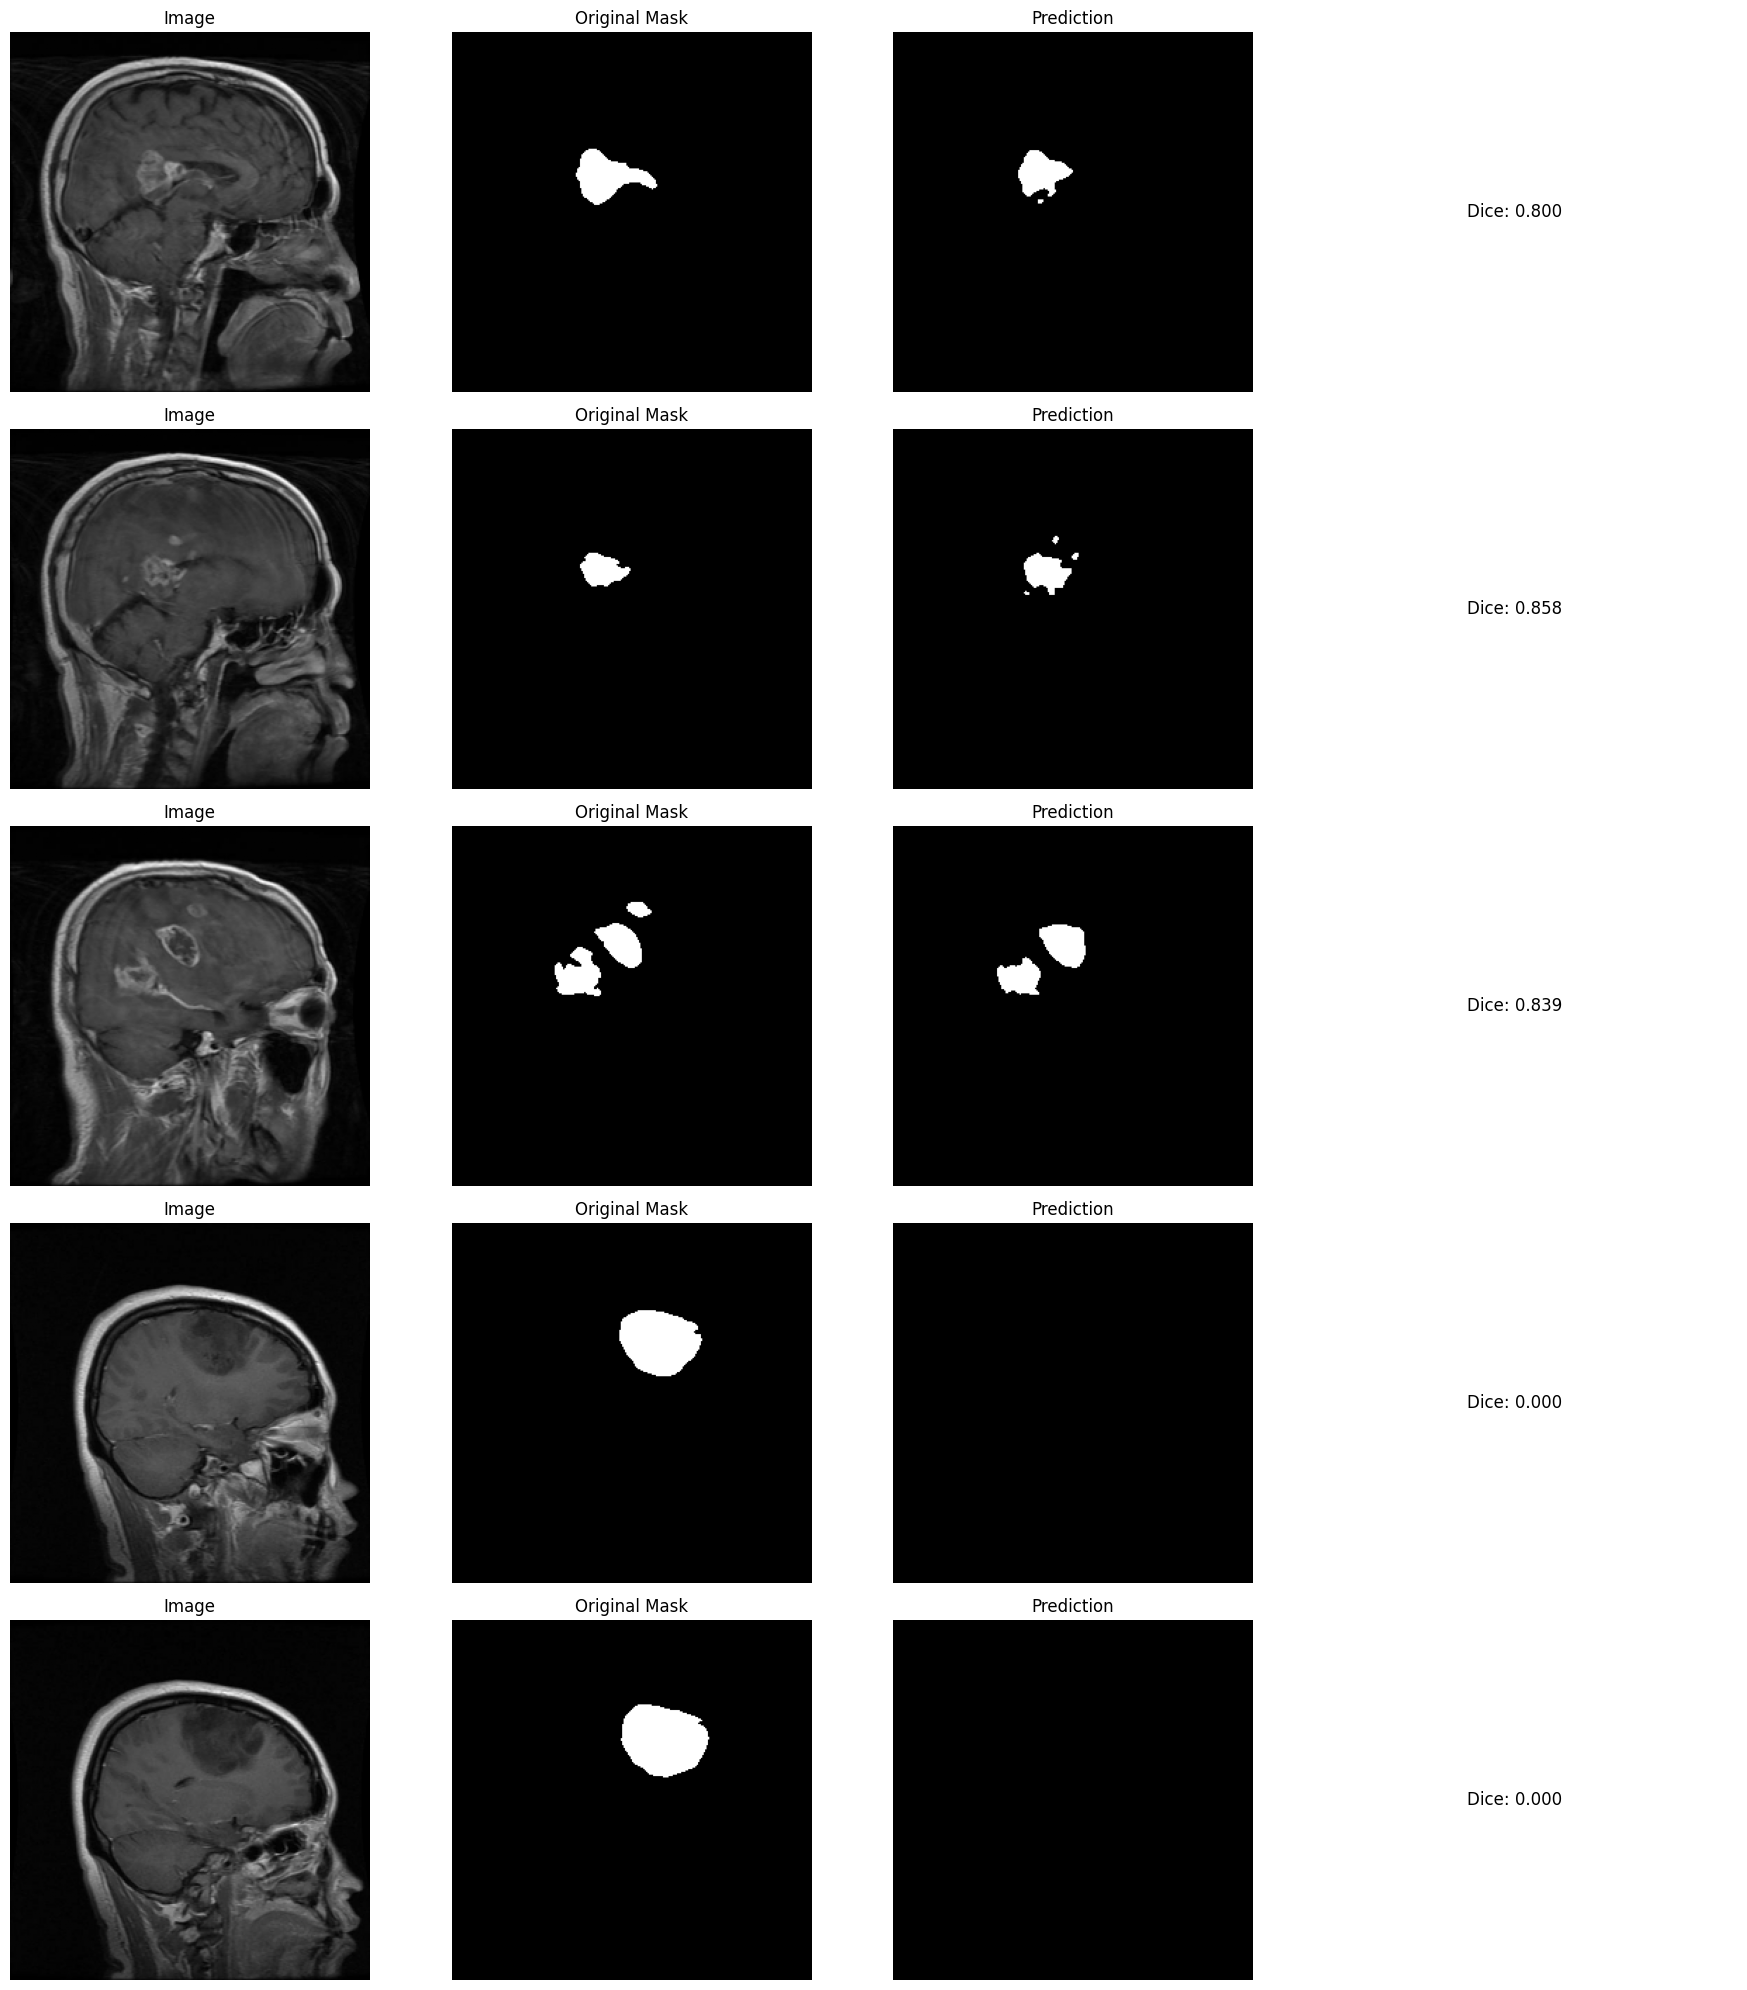

In [ ]:
model_name = "Classic U-Net"
metrics_unet = evaluate_model(model_name, U_net_model, test_ds, threshold=0.5, num_examples=5)
params_unet  = get_param_counts(U_net_model)
lat_unet     = benchmark_latency_ms_per_image(U_net_model, test_ds, warmup_batches=3, timed_batches=10)

In [ ]:
# Save model
U_net_model.save('/content/best_unet_brisc2025.keras')
print("Model saved as best_unet_brisc2025.keras")

Model saved as best_unet_brisc2025.keras


# U-Net with MobileNetV2 Encoder

In [ ]:
from tensorflow.keras.applications import MobileNetV2

def unet_mobilenetv2(input_shape=(256, 256, 3), freeze_encoder=True):
    inputs = layers.Input(input_shape)

    # Pre-trained encoder (ImageNet weights)
    base = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs,
        alpha=1.0
    )

    if freeze_encoder:
        base.trainable = False

    # Skip connections
    skips = [
        base.get_layer('expanded_conv_project_BN').output,     # ~128×128×16
        base.get_layer('block_3_expand_relu').output,          # ~64×64×144
        base.get_layer('block_6_expand_relu').output,          # ~32×32×192
        base.get_layer('block_13_expand_relu').output          # ~16×16×576
    ]

    # Bottleneck (last feature map)
    x = base.output  # shape ~8×8×1280 for 256 input

    # Decoder - 5 upsampling steps to reach 256×256
    # Level 1: 8→16
    x = layers.Conv2DTranspose(512, 2, strides=2, padding='same', activation='relu')(x)
    x = layers.concatenate([x, skips[3]])  # 16×16×(512 + 576)
    x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)

    # Level 2: 16→32
    x = layers.Conv2DTranspose(256, 2, strides=2, padding='same', activation='relu')(x)
    x = layers.concatenate([x, skips[2]])  # 32×32×(256 + 192)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)

    # Level 3: 32→64
    x = layers.Conv2DTranspose(128, 2, strides=2, padding='same', activation='relu')(x)
    x = layers.concatenate([x, skips[1]])  # 64×64×(128 + 144)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)

    # Level 4: 64→128
    x = layers.Conv2DTranspose(64, 2, strides=2, padding='same', activation='relu')(x)
    x = layers.concatenate([x, skips[0]])  # 128×128×(64 + 16)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)

    # Level 5: 128→256 (new block!)
    x = layers.Conv2DTranspose(32, 2, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)

    # Final output
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)  # (None, 256, 256, 1)

    model = models.Model(inputs, outputs, name='U-Net_MobileNetV2')
    return model

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenetv2_preprocess

def preprocess_rgb_mobilenet(img, mask):
    # img is currently grayscale in [0,1]
    img = tf.image.grayscale_to_rgb(img)      # -> (H,W,3)
    img = tf.cast(img, tf.float32) * 255.0    # -> [0,255]
    img = mobilenetv2_preprocess(img)         # -> backbone expected range (typically [-1,1])
    return img, mask

# Update datasets
train_ds_mob = train_ds.map(preprocess_rgb_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_mob   = val_ds.map(preprocess_rgb_mobilenet,   num_parallel_calls=tf.data.AUTOTUNE)
test_ds_mob  = test_ds.map(preprocess_rgb_mobilenet,  num_parallel_calls=tf.data.AUTOTUNE)

model_mob = unet_mobilenetv2(input_shape=(256, 256, 3))
model_mob.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss=combined_loss,
                  metrics=[dice_coef, binary_iou, 'binary_accuracy'])
model_mob.summary()

# Callbacks
callbacks_list = [
    callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_dice_coef', mode='max'),
    callbacks.ReduceLROnPlateau(patience=5, factor=0.5, monitor='val_dice_coef', mode='max'),
    callbacks.ModelCheckpoint('best_mobilenetv2_unet_brisc2025.keras', save_best_only=True, monitor='val_dice_coef', mode='max')
]

# Training
EPOCHS = 20
model_mob_history = model_mob.fit(
    train_ds_mob,
    validation_data=val_ds_mob,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

/tmp/ipython-input-327548311.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "U-Net_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 15,135,745 (57.74 MB)

 Trainable params: 12,877,761 (49.12 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 97s 301ms/step - binary_accuracy: 0.8578 - binary_iou: 0.0329 - dice_coef: 0.1070 - loss: 1.1700 - val_binary_accuracy: 0.9897 - val_binary_iou: 0.4729 - val_dice_coef: 0.6206 - val_loss: 0.4249 - learning_rate: 1.0000e-04
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - binary_accuracy: 0.9902 - binary_iou: 0.5198 - dice_coef: 0.6615 - loss: 0.3834 - val_binary_accuracy: 0.9913 - val_binary_iou: 0.5932 - val_dice_coef: 0.7246 - val_loss: 0.3145 - learning_rate: 1.0000e-04
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - binary_accuracy: 0.9928 - binary_iou: 0.6240 - dice_coef: 0.7537 - loss: 0.2829 - val_binary_accuracy: 0.9927 - val_binary_iou: 0.6397 - val_dice_coef: 0.7619 - val_loss: 0.2726 - learning_rate: 1.0000e-04
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - binary_accuracy: 0.9934 - binary_iou: 0.6580 - dice_coef: 0.7794 - loss: 0.2550 - val_binary_accuracy: 0.9931 - val_binary_iou: 0.6611 - val_dice_coef: 0.782

U-Net + MobileNetV2 ran for ~4 mins


Evaluating model: U-Net + MobileNetV2

Summary

────────────────────────────────────────────────────────────
Pixel-level Metrics (threshold = 0.5):
  Dice Coefficient:     0.8692
  IoU (Jaccard Index):  0.7687
  Precision:            0.9081
  Recall:               0.8335
  Pixel Accuracy:       0.9952
────────────────────────────────────────────────────────────

 Qualitative predictions – 5 sample cases



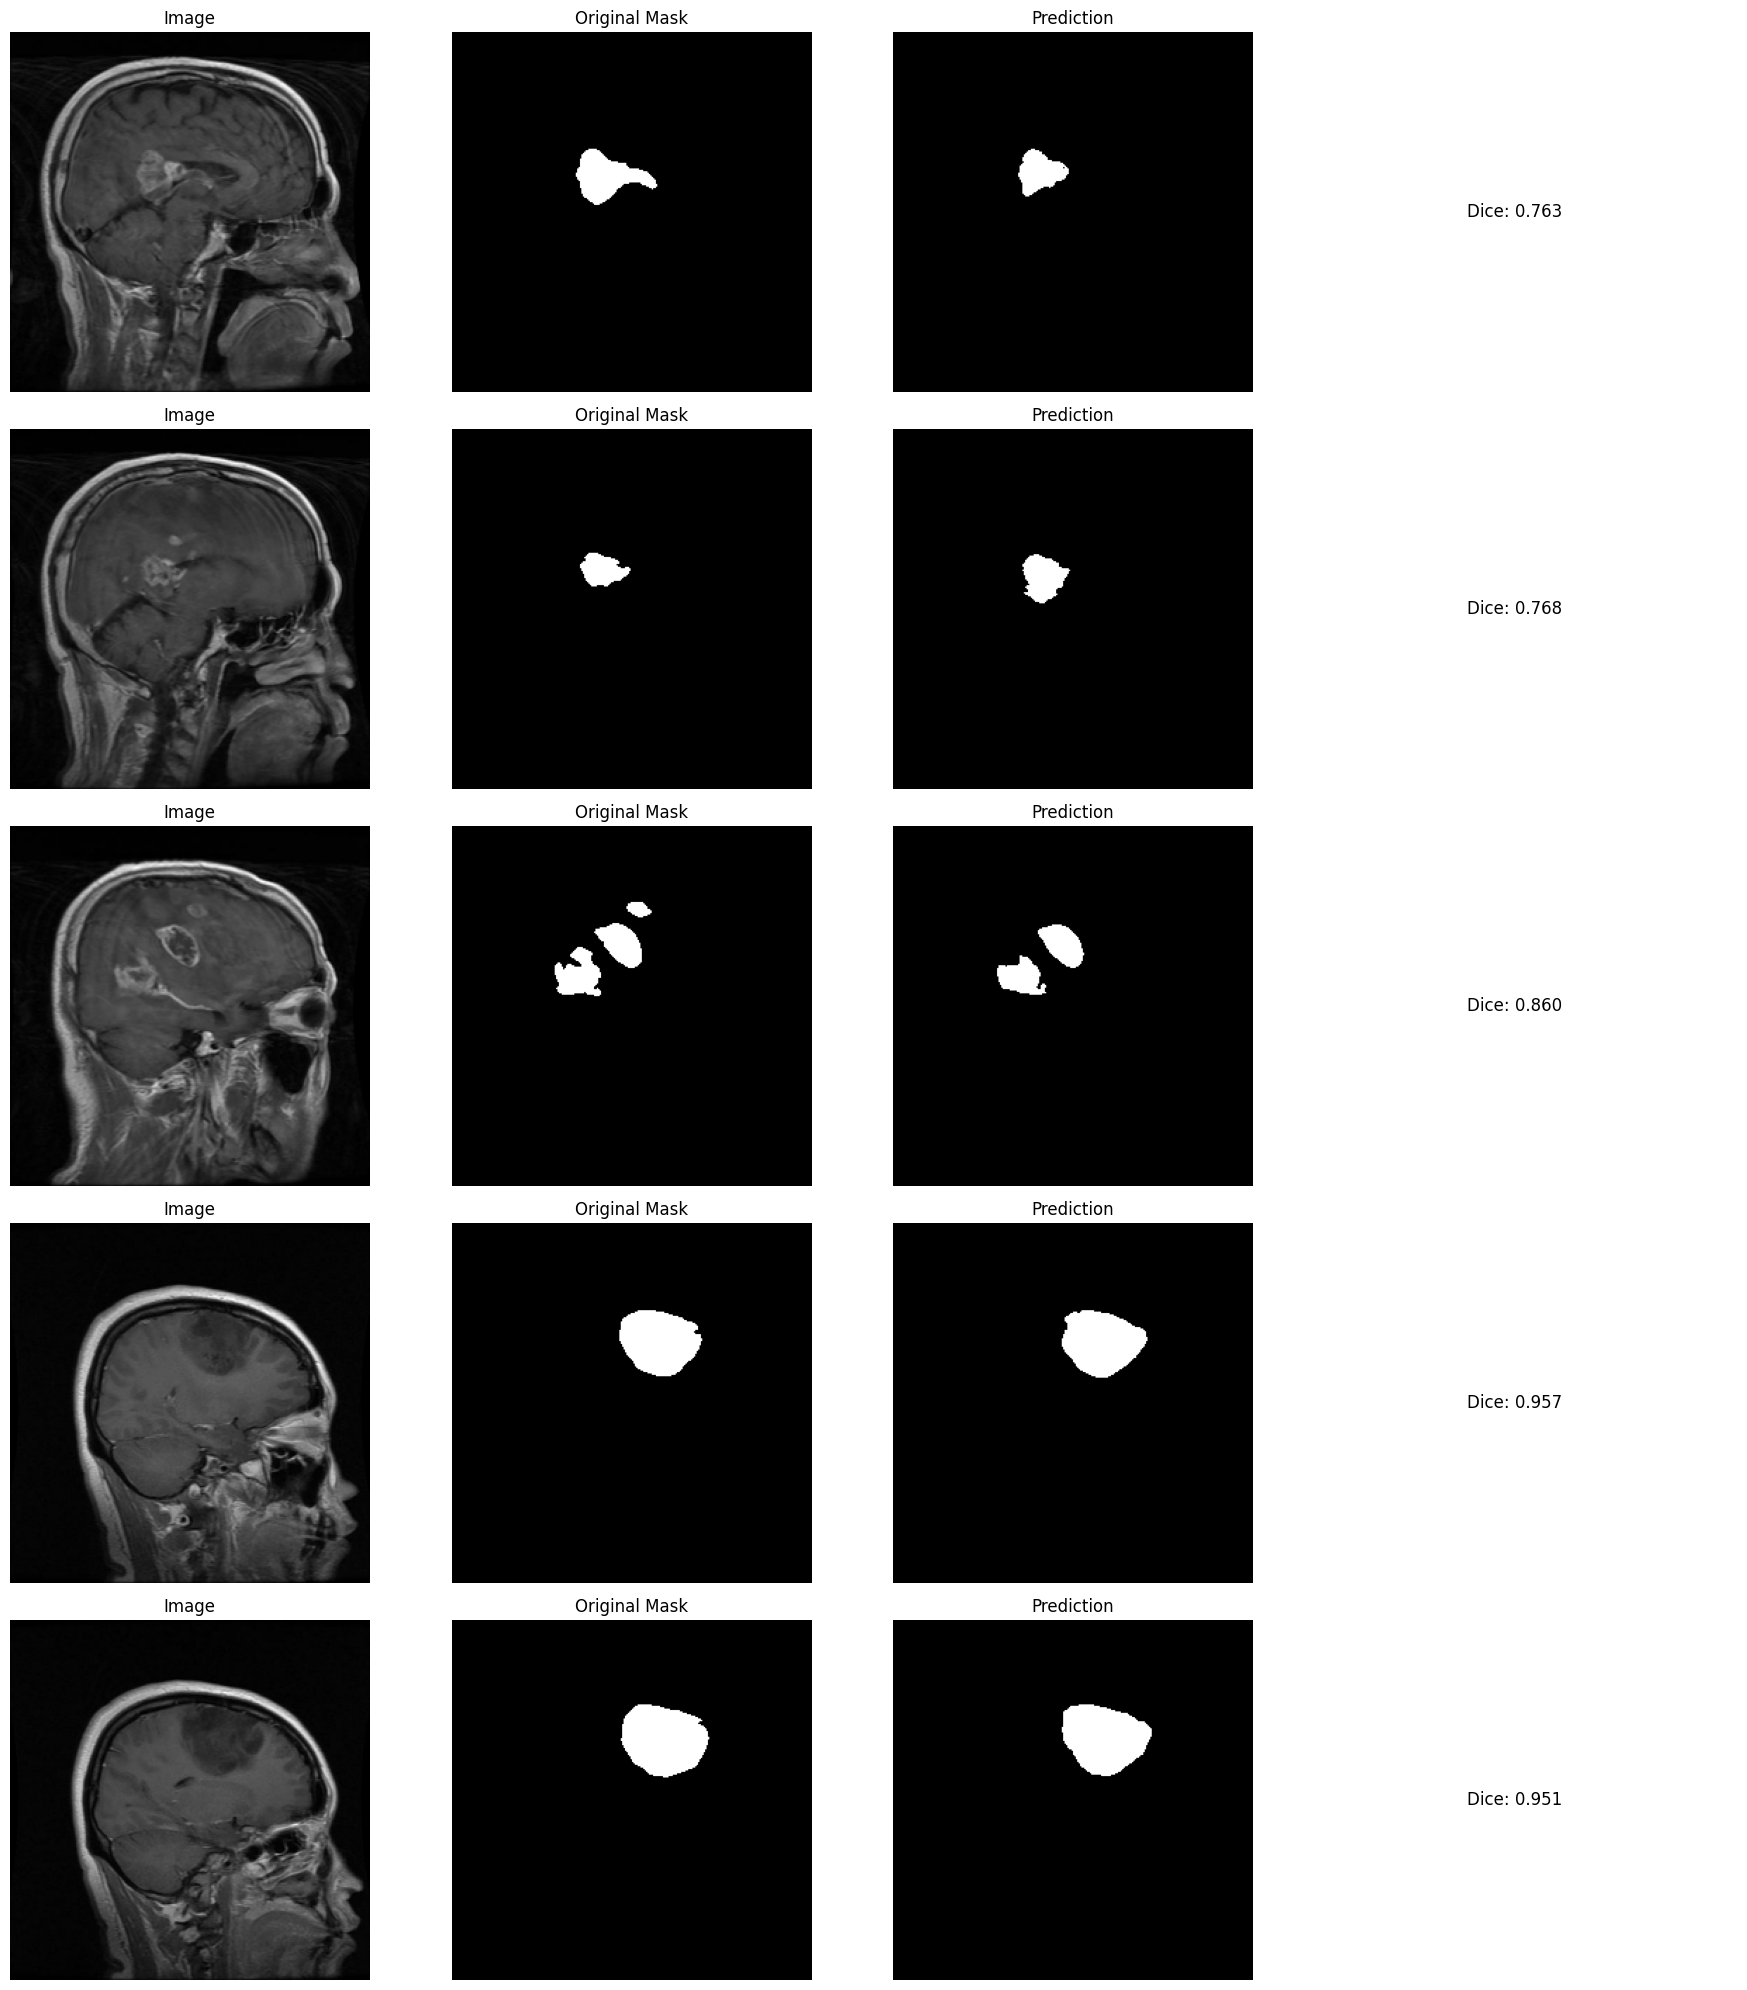

In [ ]:
model_name= "U-Net + MobileNetV2"
metrics_mob = evaluate_model(model_name, model_mob, test_ds_mob, threshold=0.5, num_examples=5)
params_mob  = get_param_counts(model_mob)
lat_mob     = benchmark_latency_ms_per_image(model_mob, test_ds_mob, warmup_batches=3, timed_batches=10)

In [ ]:
# Save model
model_mob.save('/content/best_mobilenetv2_unet_brisc2025.keras')
print("Model saved as best_mobilenetv2_unet_brisc2025.keras")

Model saved as best_mobilenetv2_unet_brisc2025.keras


# U-Net with ResNet50 Encoder

In [ ]:
from tensorflow.keras.applications import ResNet50

def unet_resnet50(input_shape=(256, 256, 3), freeze_encoder=True):
    inputs = layers.Input(input_shape)

    base = ResNet50(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )

    if freeze_encoder:
        base.trainable = False

    # Skip connections (correct layer names for ResNet50)
    skips = [
        base.get_layer('conv1_relu').output,          # 128×128×64   (after first conv)
        base.get_layer('conv2_block3_out').output,    # 64×64×256
        base.get_layer('conv3_block4_out').output,    # 32×32×512
        base.get_layer('conv4_block6_out').output     # 16×16×1024
    ]

    x = base.output  # conv5_block3_out → 8×8×2048

    # Decoder with 5 upsampling steps: 8→16→32→64→128→256
    # Filters scaled down slightly for efficiency
    x = layers.Conv2DTranspose(1024, 2, strides=2, padding='same', activation='relu')(x)  # 16×16
    x = layers.concatenate([x, skips[3]])  # 16×16×(1024 + 1024)
    x = layers.Conv2D(1024, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(1024, 3, padding='same', activation='relu')(x)

    x = layers.Conv2DTranspose(512, 2, strides=2, padding='same', activation='relu')(x)   # 32×32
    x = layers.concatenate([x, skips[2]])  # 32×32×(512 + 512)
    x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)

    x = layers.Conv2DTranspose(256, 2, strides=2, padding='same', activation='relu')(x)   # 64×64
    x = layers.concatenate([x, skips[1]])  # 64×64×(256 + 256)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)

    x = layers.Conv2DTranspose(128, 2, strides=2, padding='same', activation='relu')(x)   # 128×128
    x = layers.concatenate([x, skips[0]])  # 128×128×(128 + 64)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)

    # Extra upsampling to reach 256×256
    x = layers.Conv2DTranspose(64, 2, strides=2, padding='same', activation='relu')(x)    # 256×256
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs, name='U-Net_ResNet50')
    return model

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess

def preprocess_rgb_resnet(img, mask):
    img = tf.image.grayscale_to_rgb(img)
    img = tf.cast(img, tf.float32) * 255.0
    img = resnet50_preprocess(img)            # ResNet50 expected preprocessing
    return img, mask

# Update datasets
train_ds_res = train_ds.map(preprocess_rgb_resnet, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_res   = val_ds.map(preprocess_rgb_resnet,   num_parallel_calls=tf.data.AUTOTUNE)
test_ds_res  = test_ds.map(preprocess_rgb_resnet,  num_parallel_calls=tf.data.AUTOTUNE)

model_res = unet_resnet50(input_shape=(256, 256, 3))
model_res.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss=combined_loss,
                  metrics=[dice_coef, binary_iou, 'binary_accuracy'])
model_res.summary()

# Callbacks
callbacks_list = [
    callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_dice_coef', mode='max'),
    callbacks.ReduceLROnPlateau(patience=5, factor=0.5, monitor='val_dice_coef', mode='max'),
    callbacks.ModelCheckpoint('best_model_res_brisc2025.keras', save_best_only=True, monitor='val_dice_coef', mode='max')
]

# Training
EPOCHS = 20
model_res_history = model_res.fit(
    train_ds_res,
    validation_data=val_ds_res,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "U-Net_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 72,368,897 (276.07 MB)

 Trainable params: 48,781,185 (186.09 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 62s 197ms/step - binary_accuracy: 0.9164 - binary_iou: 0.1159 - dice_coef: 0.1829 - loss: 1.0068 - val_binary_accuracy: 0.9915 - val_binary_iou: 0.5565 - val_dice_coef: 0.7015 - val_loss: 0.3391 - learning_rate: 1.0000e-04
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - binary_accuracy: 0.9919 - binary_iou: 0.5874 - dice_coef: 0.7257 - loss: 0.3139 - val_binary_accuracy: 0.9929 - val_binary_iou: 0.6305 - val_dice_coef: 0.7600 - val_loss: 0.2690 - learning_rate: 1.0000e-04
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - binary_accuracy: 0.9937 - binary_iou: 0.6686 - dice_coef: 0.7889 - loss: 0.2428 - val_binary_accuracy: 0.9940 - val_binary_iou: 0.6553 - val_dice_coef: 0.7817 - val_loss: 0.2483 - learning_rate: 1.0000e-04
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - binary_accuracy: 0.9937 - binary_iou: 0.6681 - dice_coef: 0.7896 - loss: 0.2427 - val_binary_accuracy: 0.9940 - val_binary_iou: 0.6825 - val_dice_coef: 0.803

U-Net + ResNet50 ran for ~7 mins


Evaluating model: U-Net + ResNet50

Summary

────────────────────────────────────────────────────────────
Pixel-level Metrics (threshold = 0.5):
  Dice Coefficient:     0.8820
  IoU (Jaccard Index):  0.7889
  Precision:            0.9171
  Recall:               0.8495
  Pixel Accuracy:       0.9957
────────────────────────────────────────────────────────────

 Qualitative predictions – 5 sample cases



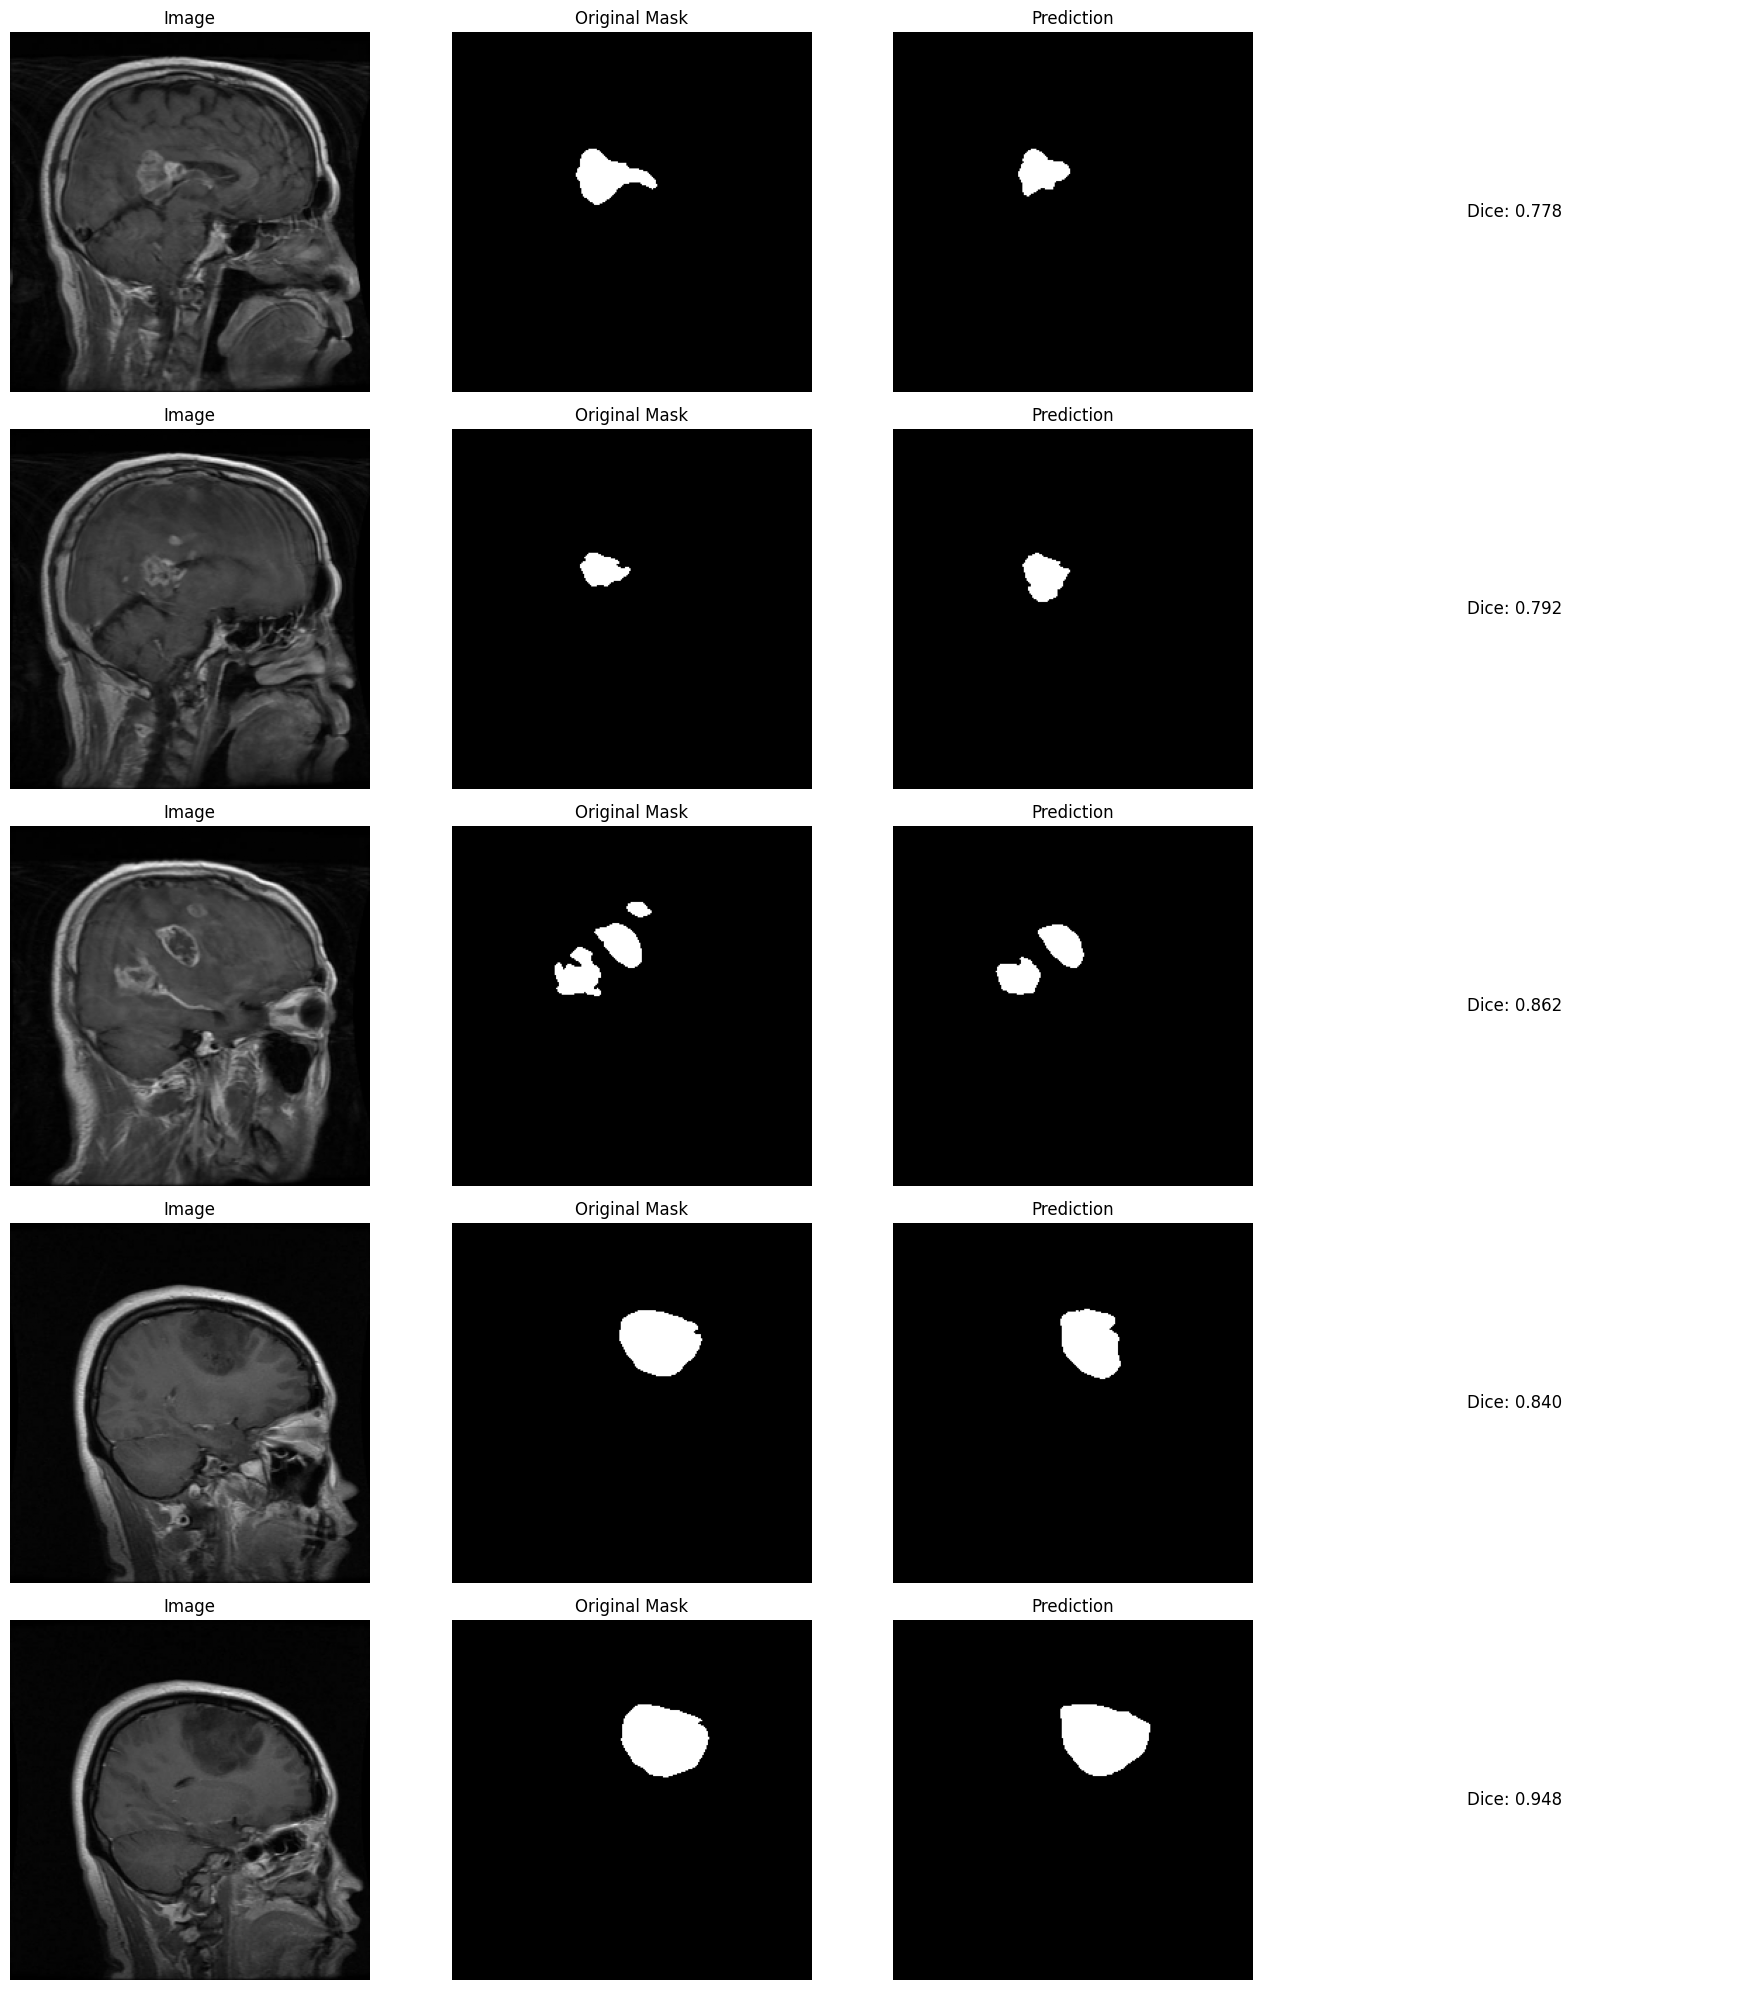

In [ ]:
model_name= "U-Net + ResNet50"
metrics_res = evaluate_model(model_name, model_res, test_ds_res, threshold=0.5, num_examples=5)
params_res  = get_param_counts(model_res)
lat_res     = benchmark_latency_ms_per_image(model_res, test_ds_res, warmup_batches=3, timed_batches=10)

In [ ]:
# Save model
model_res.save('/content/best_model_res_brisc2025.keras')
print("Model saved as best_model_res_brisc2025.keras")

Model saved as best_model_res_brisc2025.keras


# Comparison Table

In [ ]:
results = [
    {"Model": "Classic U-Net",         **metrics_unet, **params_unet, **lat_unet},
    {"Model": "U-Net + MobileNetV2",   **metrics_mob,  **params_mob,  **lat_mob},
    {"Model": "U-Net + ResNet50",      **metrics_res,  **params_res,  **lat_res},
]

import pandas as pd
results_df = pd.DataFrame(results)

col_order = [
    "Model",
    "Dice", "IoU", "Precision", "Recall", "Pixel Accuracy",
    "Total Params", "Trainable Params", "Non-trainable Params",
    "Latency (ms/img)"
]
results_df = results_df[[c for c in col_order if c in results_df.columns]]

display(results_df)
results_df.to_csv("Table1_main_results_with_params.csv", index=False)
print("Saved: Table1_main_results_with_params.csv")


,Model,Dice,IoU,Precision,Recall,Pixel Accuracy,Total Params,Trainable Params,Non-trainable Params,Latency (ms/img)
0,Classic U-Net,0.795269,0.660122,0.870530,0.731987,0.992819,31030593,31030593,0,5.973147
1,U-Net + MobileNetV2,0.869210,0.768676,0.908114,0.833503,0.995221,15135745,12877761,2257984,5.717559
2,U-Net + ResNet50,0.881978,0.788874,0.917083,0.849462,0.995669,72368897,48781185,23587712,6.683170


Saved: Table1_main_results_with_params.csv


# Evaluation curves

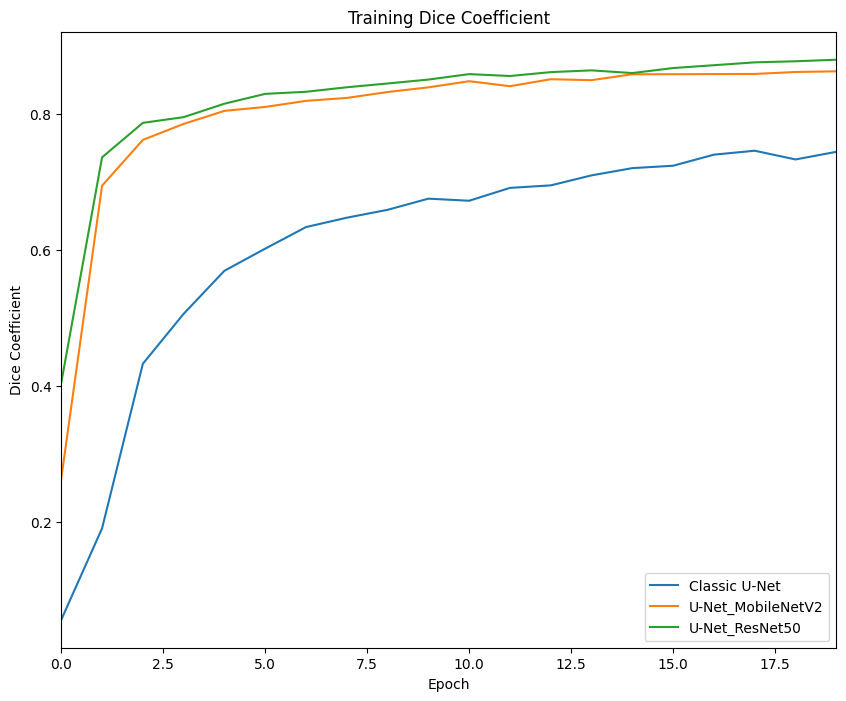

In [ ]:
import matplotlib.pyplot as plt

# Accuracy values
acc_U_net_model = history.history['dice_coef']
acc_model_mob = model_mob_history.history['dice_coef']
acc_model_res = model_res_history.history['dice_coef']

beingsaved = plt.figure(figsize=(10, 8))

plt.plot(acc_U_net_model, label='Classic U-Net')
plt.plot(acc_model_mob, label='U-Net_MobileNetV2')
plt.plot(acc_model_res, label='U-Net_ResNet50')

plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.title("Training Dice Coefficient")
# Set legend in bottom-right corner
plt.legend(loc='lower right')
#plt.ylim(0, 1)
# Remove gap from the y-axis
plt.gca().margins(x=0)

beingsaved.savefig('Training Dice Coefficient.png', format='png', dpi=600, bbox_inches="tight")
plt.show()

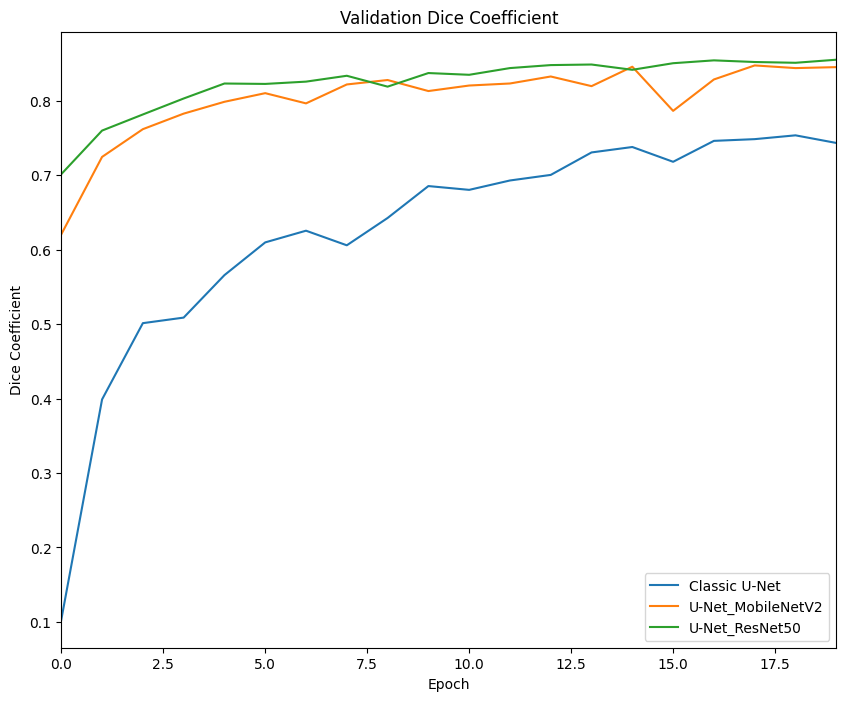

In [ ]:
# Accuracy values
acc_U_net_model = history.history['val_dice_coef']
acc_model_mob = model_mob_history.history['val_dice_coef']
acc_model_res = model_res_history.history['val_dice_coef']

beingsaved = plt.figure(figsize=(10, 8))

plt.plot(acc_U_net_model, label='Classic U-Net')
plt.plot(acc_model_mob, label='U-Net_MobileNetV2')
plt.plot(acc_model_res, label='U-Net_ResNet50')

plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.title("Validation Dice Coefficient")
# Set legend in bottom-right corner
plt.legend(loc='lower right')
#plt.ylim(0, 1)
# Remove gap from the y-axis
plt.gca().margins(x=0)

beingsaved.savefig('Validation Dice Coefficient.png', format='png', dpi=600, bbox_inches="tight")
plt.show()

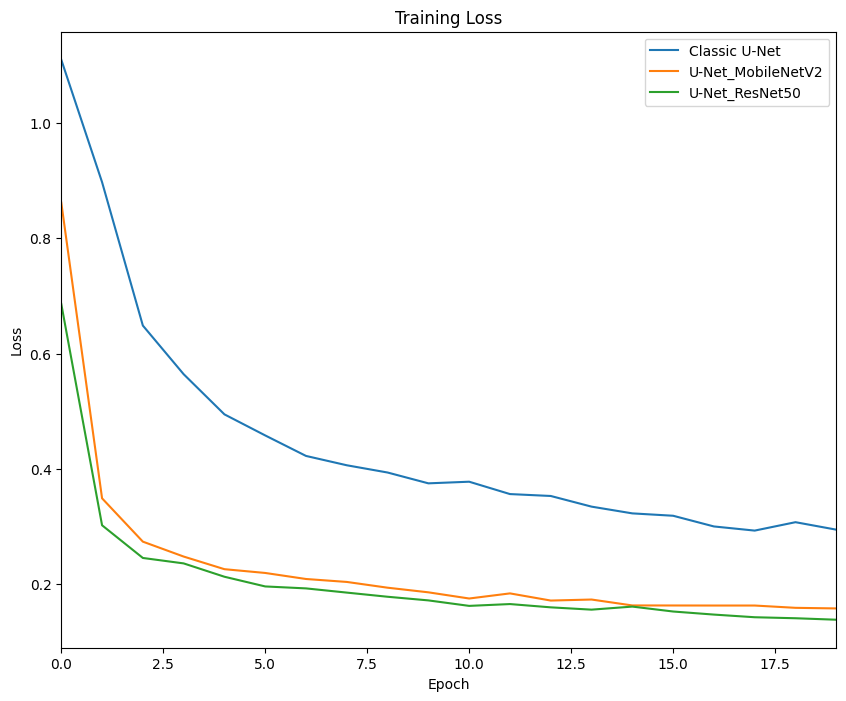

In [ ]:
# Accuracy values
acc_U_net_model = history.history['loss']
acc_model_mob = model_mob_history.history['loss']
acc_model_res = model_res_history.history['loss']

beingsaved = plt.figure(figsize=(10, 8))

plt.plot(acc_U_net_model, label='Classic U-Net')
plt.plot(acc_model_mob, label='U-Net_MobileNetV2')
plt.plot(acc_model_res, label='U-Net_ResNet50')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Training Loss")
# Set legend in bottom-right corner
plt.legend(loc='upper right')
#plt.ylim(0, 1)
# Remove gap from the y-axis
plt.gca().margins(x=0)

beingsaved.savefig('Training Loss.png', format='png', dpi=600, bbox_inches="tight")
plt.show()

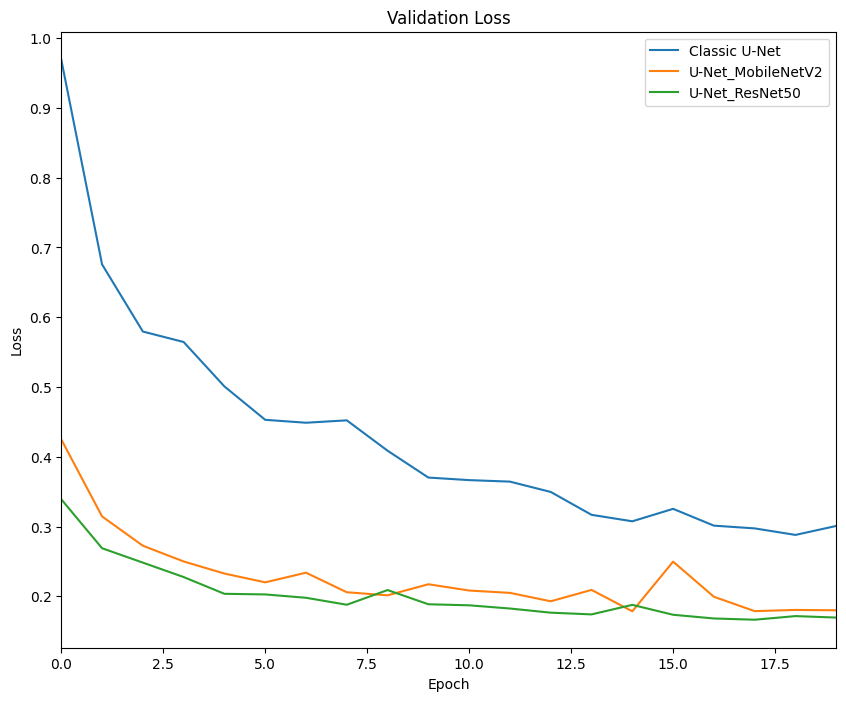

In [ ]:
# Accuracy values
acc_U_net_model = history.history['val_loss']
acc_model_mob = model_mob_history.history['val_loss']
acc_model_res = model_res_history.history['val_loss']

beingsaved = plt.figure(figsize=(10, 8))

plt.plot(acc_U_net_model, label='Classic U-Net')
plt.plot(acc_model_mob, label='U-Net_MobileNetV2')
plt.plot(acc_model_res, label='U-Net_ResNet50')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Validation Loss")
# Set legend in bottom-right corner
plt.legend(loc='upper right')
#plt.ylim(0, 1)
# Remove gap from the y-axis
plt.gca().margins(x=0)

beingsaved.savefig('Validation Loss.png', format='png', dpi=600, bbox_inches="tight")
plt.show()